# Linear Models

Check the performance of SVM and logistic regression on our engineered data sets before moving to more complex models.

In [1]:
%reload_ext autoreload
%autoreload 2
import sys, os
import pandas as pd
import warnings
import numpy as np
from pathlib import Path

warnings.filterwarnings('ignore')
DATA_DIR = Path('../src/shared_util/data')
METRICS_DIR = DATA_DIR
CSV_PATH = METRICS_DIR / 'metrics.csv'
LOG = True



from shared_util.metrics import metrics_db
from shared_util.dataio import load_csv



if LOG:
    metrics_db.read_in(CSV_PATH)

METRICS_DB_ID = 1 # update this to not overwrite previous metrics for these models
METRIC_NOTES = "with log transform" # global metric notes for this run



In [2]:
df = load_csv('cleaned')
df.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,target
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,0
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,?,...,No,Up,No,No,No,No,No,Ch,Yes,0
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,?,...,No,No,No,No,No,No,No,No,Yes,0
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,?,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,?,...,No,Steady,No,No,No,No,No,Ch,Yes,0


In [3]:
from shared_util.split import group_split

X_train, X_validate, X_test, y_train, y_validate, y_test = group_split(df)

In [4]:
LOG_TRANSFORM_COLS = np.array(
    ['number_outpatient', 'number_inpatient', 'number_emergency', 
     'num_medications', 'num_procedures', 'time_in_hospital'
     ])

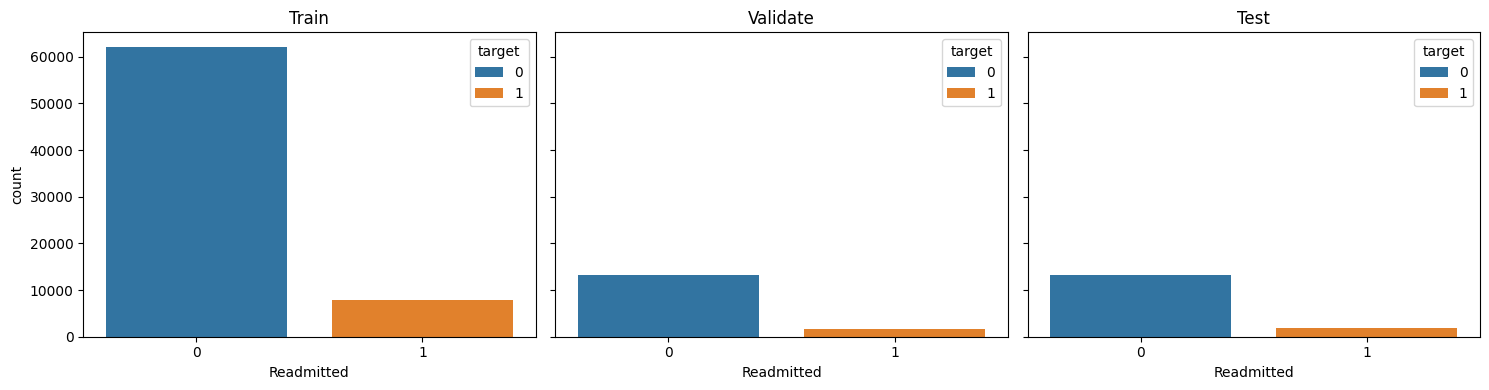

In [5]:
from shared_util.metrics.printing import check_y_dist

check_y_dist(
    y_train,
    y_validate,
    y_test
)

In [6]:
from shared_util.pipeline import CleaningPipeline

def make_cleaning_pipe():
    return CleaningPipeline(create_interactions=True,log_transform_cols=LOG_TRANSFORM_COLS)


## Baseline Logistic Regression

In [7]:
from sklearn.linear_model import SGDClassifier
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler
from shared_util.pipeline import CleaningPipeline

from shared_util.baseline import get_baseline_score
from imblearn.pipeline import Pipeline




print('Baseline SGD Classifier')

roc_auc = get_baseline_score(
    SGDClassifier(random_state=42),
    RandomUnderSampler(random_state=42),
    X_train,
    y_train,
    scaler=StandardScaler(),
    preprocessor=make_cleaning_pipe()
    )


if LOG:
    metrics_db.log_metric(
        metric_id=METRICS_DB_ID,
        model='sgd',
        threshold_notes='base',
        data='train',
        pipeline_notes='under_sample',
        notes=METRIC_NOTES,
        roc_auc=roc_auc
    )



Baseline SGD Classifier
roc_auc score per fold:  [0.59129878 0.61058798 0.59416152 0.58814508 0.59676724]
mean roc_auc score:  0.596192119554133
logged row: (1, sgd, train, base, under_sample)


In [8]:
# try SMOTE
from imblearn.over_sampling import SMOTE

print('Baseline ROC_AUC using SMOTE')

roc_auc = get_baseline_score(
    SGDClassifier(random_state=42),
    SMOTE(random_state=42),
    X_train,
    y_train,
    scaler=StandardScaler(),
    preprocessor=CleaningPipeline(create_interactions=True)
    )

if LOG:
    metrics_db.log_metric(
        metric_id=METRICS_DB_ID,
        threshold_notes='base',
        data='train',
        model='sgd',
        pipeline_notes='SMOTE',
        notes=METRIC_NOTES,
        roc_auc=roc_auc
    )


Baseline ROC_AUC using SMOTE
roc_auc score per fold:  [0.56648847 0.54952741 0.55361943 0.54450532 0.53704529]
mean roc_auc score:  0.5502371863555668
logged row: (1, sgd, train, base, SMOTE)


In [9]:
def make_base_sgd(use_smote=False):
    return Pipeline([
        ('preprocessor', make_cleaning_pipe()),
        ('sampler',SMOTE(random_state=42) if use_smote else RandomUnderSampler(random_state=42)),
        ('scaler', StandardScaler()),
        ('model', SGDClassifier(random_state=42))
    ])

In [10]:
# hyperparam search for SGD
from sklearn.model_selection import RandomizedSearchCV
from shared_util.baseline import make_group_cv


sgd_param_grid = {
    "model__loss": ["log_loss", "modified_huber", "hinge", "squared_hinge"],
    "model__penalty": ["l2", "l1", "elasticnet"],
    "model__alpha": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2],
    "model__l1_ratio": [0.1, 0.5, 0.9],
    "model__learning_rate": ["constant", "optimal", "invscaling", "adaptive"],
    "model__eta0": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1],
    "model__max_iter": [100, 500, 1000],
    "model__tol": [1e-3, 1e-4],
    "model__class_weight": [None, "balanced"],
    "model__average": [False, True, 5, 10],
    "model__shuffle": [True],
}

rs = RandomizedSearchCV(
    estimator=make_base_sgd(),
    param_distributions=sgd_param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=make_group_cv(),
    n_jobs=-1,
    random_state=42,
    refit=True
)

rs.fit(X_train, y_train, groups=X_train['patient_nbr'])

print(f'Best ROC_AUC (cv): {rs.best_score_}')
print(f'best params: {rs.best_params_}')

res_df = pd.DataFrame(
    rs.cv_results_
).sort_values('rank_test_score').reset_index(drop=True)
res_df[['rank_test_score','mean_test_score','std_test_score','params']].head(10)

Best ROC_AUC (cv): 0.65636925915964
best params: {'model__tol': 0.0001, 'model__shuffle': True, 'model__penalty': 'l1', 'model__max_iter': 500, 'model__loss': 'modified_huber', 'model__learning_rate': 'invscaling', 'model__l1_ratio': 0.9, 'model__eta0': 0.003, 'model__class_weight': None, 'model__average': 10, 'model__alpha': 0.001}


,rank_test_score,mean_test_score,std_test_score,params
0,1,0.656369,0.007494,"{'model__tol': 0.0001, 'model__shuffle': True,..."
1,2,0.656031,0.007504,"{'model__tol': 0.001, 'model__shuffle': True, ..."
2,3,0.655924,0.007489,"{'model__tol': 0.001, 'model__shuffle': True, ..."
3,4,0.655897,0.007922,"{'model__tol': 0.001, 'model__shuffle': True, ..."
4,5,0.655799,0.007575,"{'model__tol': 0.001, 'model__shuffle': True, ..."
5,6,0.655657,0.007049,"{'model__tol': 0.0001, 'model__shuffle': True,..."
6,7,0.654964,0.007961,"{'model__tol': 0.0001, 'model__shuffle': True,..."
7,8,0.653495,0.007876,"{'model__tol': 0.001, 'model__shuffle': True, ..."
8,9,0.649159,0.006692,"{'model__tol': 0.0001, 'model__shuffle': True,..."
9,10,0.646891,0.007669,"{'model__tol': 0.0001, 'model__shuffle': True,..."


In [10]:
# Best ROC_AUC (cv): 0.6549746228889155
# best params: {'model__tol': 0.001, 'model__shuffle': True, 'model__penalty': 'l1', 'model__max_iter': 1000, 'model__loss': 'log_loss', 'model__learning_rate': 'constant', 'model__l1_ratio': 0.1, 'model__eta0': 0.0003, 'model__class_weight': 'balanced', 'model__average': False, 'model__alpha': 0.0001}

In [11]:
# predict on validate set before threshold changes
from shared_util.metrics.scoring import get_scores, best_threshold_by_fbeta, plot_scoring
from shared_util.metrics.printing import print_metrics

sgd_est = rs.best_estimator_
sgd_scores = get_scores(sgd_est, X_validate)

y_pred = rs.best_estimator_.predict(X_validate) #type: ignore

print_metrics(
              y_true=y_validate, 
              y_pred=y_pred, 
              y_proba=sgd_scores,
              metrics_db_id=METRICS_DB_ID,
              metrics_notes=METRIC_NOTES,
              data='validate',
              model='sgd',
              hyperparam_notes='tuned best roc',
              pipeline_notes='under_sample',
              log=LOG
)



ROC_AUC:     0.6518665760761666
Accuracy:      0.6469766513669926
F1 score:      0.2687060768912774
Precision:     0.1754543818607162
Recall:        0.5735294117647058

Confusion matrix:

TN: 8751, FP: 4582, FN: 725, TP: 975

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.66      0.77     13333
           1       0.18      0.57      0.27      1700

    accuracy                           0.65     15033
   macro avg       0.55      0.61      0.52     15033
weighted avg       0.84      0.65      0.71     15033

logged row: (1, sgd, validate, base, under_sample)


Best threshold (F2): 0.4093
Precision: 0.146  Recall: 0.799  F2: 0.422


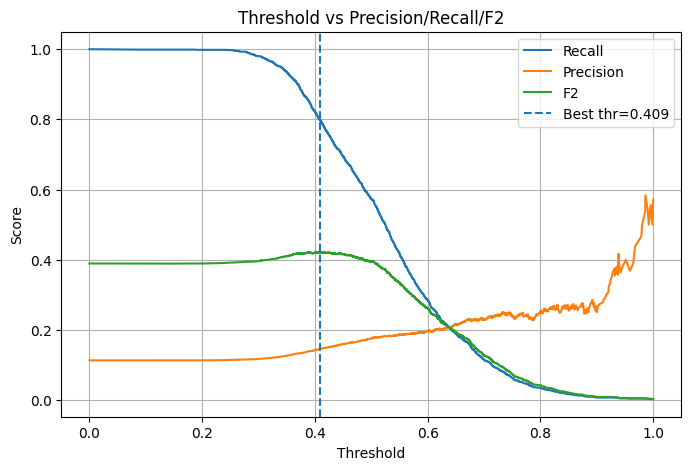

In [12]:
# decide threshold on validation set
info = best_threshold_by_fbeta(y_validate, sgd_scores, beta=2.0)
best_thresh = info['threshold']
y_pred_custom = (sgd_scores >= best_thresh).astype(int)

print(f"Best threshold (F2): {best_thresh:.4f}")
print(f"Precision: {info['precision']:.3f}  Recall: {info['recall']:.3f}  F2: {info['fbeta']:.3f}")

plot_scoring(info['curve'])

In [13]:
# use the threshold for predicitons on the held out test set

from shared_util.metrics.printing import print_metrics

sgd_scores_test = get_scores(sgd_est, X_test)

y_pred_custom_test = (sgd_scores_test >= best_thresh).astype(int)

print_metrics(
    y_true=y_test,
    y_pred=y_pred_custom_test,
    y_proba=sgd_scores_test,
    data='test',
    threshold_notes='f2_weighted',
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRIC_NOTES,
    log=LOG,
    model='sgd',
    hyperparam_notes='tuned best ROC',
    pipeline_notes='under_sample'

)

ROC_AUC:     0.6547167779208998
Accuracy:      0.4426641949152542
F1 score:      0.25504424778761065
Precision:     0.1521486643437863
Recall:        0.7878622197922361

Confusion matrix:

TN: 5245, FP: 8030, FN: 388, TP: 1441

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.40      0.55     13275
           1       0.15      0.79      0.26      1829

    accuracy                           0.44     15104
   macro avg       0.54      0.59      0.40     15104
weighted avg       0.84      0.44      0.52     15104

logged row: (1, sgd, test, f2_weighted, under_sample)


## SVM

In [14]:
# SVM
from sklearn.svm import SVC
from shared_util.baseline import get_baseline_score

roc_auc = get_baseline_score(
    SVC(random_state=42),
    RandomUnderSampler(random_state=42),
    X_train,
    y_train,
    scaler=StandardScaler(),
    preprocessor=make_cleaning_pipe()
)

if LOG:
    metrics_db.log_metric(
        metric_id=METRICS_DB_ID,
        threshold_notes='base',
        data='train',
        model='svc',
        pipeline_notes='under_sample',
        notes=METRIC_NOTES,
        roc_auc=roc_auc
    )






roc_auc score per fold:  [0.65493572 0.64942947 0.64336008 0.63926201 0.66535981]
mean roc_auc score:  0.6504694189706435
logged row: (1, svc, train, base, under_sample)


In [15]:
# running smote did not get a result after 6 hours so leaving it out for now

## Hyperparameter sweep for SVM

In [16]:
def make_base_svc(model=None):
    return Pipeline([
        ('preprocessor', make_cleaning_pipe()),
        ('sampler', RandomUnderSampler(random_state=42)),
        ('scaler', StandardScaler()),
        ('model', model if model != None else SVC(random_state=42, cache_size=16384))
    ])

In [ ]:
# this cell takes a very long time to run
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
from sklearn.model_selection import StratifiedGroupKFold


# limited param search due to computation time
svc_param_grid = {
    "model__kernel": ["rbf"],
    "model__C": loguniform(1e-3, 1e3),
    "model__gamma": [0.001, 0.01, 0.1, 1],
    "model__class_weight": ["balanced"],
    "model__shrinking": [False],
}

# reduced to 5 folds again for computation time

cv_svc = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
    )

rs_hsvc = RandomizedSearchCV(
    estimator=make_base_svc(),
    param_distributions=svc_param_grid,
   # n_iter=50,  
    scoring='roc_auc',
    cv=cv_svc,
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=2
)



rs_hsvc.fit(X_train, y_train, groups=X_train['patient_nbr'])

print(f'Best ROC_AUC (cv): {rs_hsvc.best_score_}')
print(f'Best params: {rs_hsvc.best_params_}')

res_df = pd.DataFrame(rs_hsvc.cv_results_).sort_values('rank_test_score').reset_index(drop=True)
res_df[['rank_test_score','mean_test_score','std_test_score','params']].head(10)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END model__C=0.1767016940294795, model__class_weight=balanced, model__gamma=0.001, model__kernel=rbf, model__shrinking=False; total time=  35.7s
[CV] END model__C=0.1767016940294795, model__class_weight=balanced, model__gamma=0.001, model__kernel=rbf, model__shrinking=False; total time=  35.6s
[CV] END model__C=0.1767016940294795, model__class_weight=balanced, model__gamma=0.001, model__kernel=rbf, model__shrinking=False; total time=  35.6s
[CV] END model__C=0.1767016940294795, model__class_weight=balanced, model__gamma=0.001, model__kernel=rbf, model__shrinking=False; total time=  35.8s
[CV] END model__C=0.1767016940294795, model__class_weight=balanced, model__gamma=0.001, model__kernel=rbf, model__shrinking=False; total time=  35.9s
[CV] END model__C=0.012606912518374074, model__class_weight=balanced, model__gamma=1, model__kernel=rbf, model__shrinking=False; total time=  38.8s
[CV] END model__C=0.012606912518374074, m

,rank_test_score,mean_test_score,std_test_score,params
0,1,0.651079,0.007902,"{'model__C': 0.1767016940294795, 'model__class..."
1,2,0.587933,0.006649,"{'model__C': 17.71884735480682, 'model__class_..."
2,3,0.585542,0.006745,"{'model__C': 0.4731474644815003, 'model__class..."
3,4,0.568094,0.004662,"{'model__C': 98.77700294007911, 'model__class_..."
4,5,0.566711,0.004869,"{'model__C': 3.907967156822881, 'model__class_..."
5,6,0.534085,0.004102,"{'model__C': 0.0010108171343846386, 'model__cl..."
6,7,0.534033,0.004069,"{'model__C': 0.002231010801867922, 'model__cla..."
7,8,0.533986,0.004079,"{'model__C': 0.0021800651586435186, 'model__cl..."
8,9,0.533979,0.003910,"{'model__C': 0.10051981180656774, 'model__clas..."
9,10,0.533964,0.003936,"{'model__C': 0.012606912518374074, 'model__cla..."


In [ ]:
# The above code block generates best hyperparams for our SVC model:
# Best ROC_AUC (cv): 0.6457530427983966
# Best params: {'model__C': np.float64(0.1767016940294795), 'model__class_weight': 'balanced', 'model__gamma': 0.001, 'model__kernel': 'rbf', 'model__shrinking': False}


In [17]:
# predict on validate set before threshold changes
# allows you to skip the above cell with pre computed best hyperparams
try:
    svm_est = rs_hsvc.best_estimator_
except:
    svm_est = make_base_svc(SVC(
        C=float(0.1767016940294795),
        class_weight='balanced',
        gamma=0.001,
        kernel='rbf',
        shrinking=False
    ))
    svm_est.fit(X_train, y_train)

In [18]:
svm_scores = get_scores(svm_est, X_validate)

y_pred = svm_est.predict(X_validate) #type: ignore

print_metrics(
              y_true=y_validate, 
              y_pred=y_pred, 
              y_proba=svm_scores,
              data='validate',
              metrics_db_id=METRICS_DB_ID,
              metrics_notes=METRIC_NOTES,
              model='svc',
              hyperparam_notes='tuned best roc',
              pipeline_notes='under_sample',
              log=LOG
)



ROC_AUC:     0.6499607784312256
Accuracy:      0.6846936739173818
F1 score:      0.26625386996904027
Precision:     0.18067226890756302
Recall:        0.5058823529411764

Confusion matrix:

TN: 9433, FP: 3900, FN: 840, TP: 860

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.71      0.80     13333
           1       0.18      0.51      0.27      1700

    accuracy                           0.68     15033
   macro avg       0.55      0.61      0.53     15033
weighted avg       0.83      0.68      0.74     15033

logged row: (1, svc, validate, base, under_sample)


Best threshold (F2): -0.6059
Precision: 0.154  Recall: 0.745  F2: 0.422


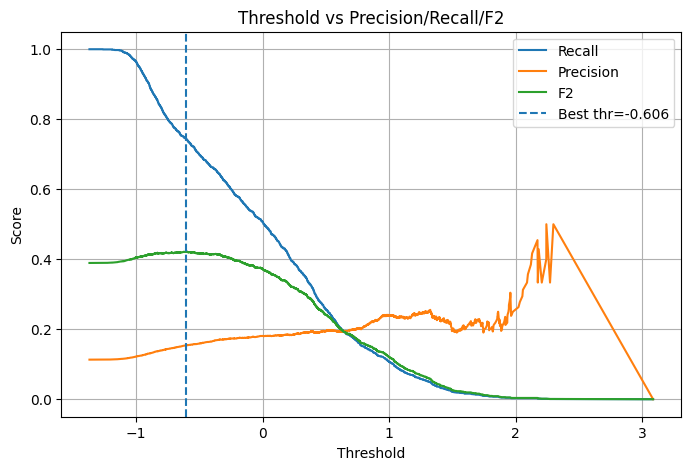

In [19]:
# threshold sweep using validation set
from shared_util.metrics.scoring import get_scores, best_threshold_by_fbeta, plot_scoring



info = best_threshold_by_fbeta(y_validate, svm_scores, beta=2.0)

best_thresh = info["threshold"]
y_pred_custom = (svm_scores >= best_thresh).astype(int)

print(f"Best threshold (F2): {best_thresh:.4f}")
print(f"Precision: {info['precision']:.3f}  Recall: {info['recall']:.3f}  F2: {info['fbeta']:.3f}")

plot_scoring(info['curve'])

In [ ]:
# held out test prediction using calculated threshold

svm_scores_test = get_scores(svm_est, X_test)

y_pred_test_svm = (svm_scores_test >= best_thresh).astype(int)


In [21]:
from shared_util.metrics.printing import print_metrics

print ('Held out test metrics for (Support Vector Classifier)')

print_metrics(
              y_true=y_test, 
              y_pred=y_pred_test_svm, 
              y_proba=svm_scores_test,
              data='test',
              threshold_notes='f2_weighted',
              metrics_db_id=METRICS_DB_ID,
              metrics_notes=METRIC_NOTES,
              model='svc',
              hyperparam_notes='tuned best roc, uses HalvingRandomSearchCV',
              pipeline_notes='under_sample',
              log=LOG
              )

Held out test metrics for (Support Vector Classifier)
ROC_AUC:     0.6470033226969962
Accuracy:      0.5035752118644068
F1 score:      0.26316823899371067
Precision:     0.16041691625733798
Recall:        0.7320940404592674

Confusion matrix:

TN: 6267, FP: 7008, FN: 490, TP: 1339

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.47      0.63     13275
           1       0.16      0.73      0.26      1829

    accuracy                           0.50     15104
   macro avg       0.54      0.60      0.44     15104
weighted avg       0.83      0.50      0.58     15104

logged row: (1, svc, test, f2_weighted, under_sample)


Both SVM and the SGD classifier both achieved above expected results compared to previous literature, which showed linear models performing, generally, with a ROC_AUC below 0.600.



In [22]:
metrics_db.close(write=True) # remove the db dataframe from memory to prevent weirdness when running multiple notebooks